# Credit Card Fraud Detection Using Machine Learning

**Author:** Willis Dongmo  
**Date:** April 2026  

---

## Project Overview

Binary classification project to detect fraudulent credit card transactions using XGBoost and Neural Networks.

**Context:** Academic project demonstrating practical ML implementation for imbalanced classification.

---

## Introduction

This project aims to predict whether a credit card transaction is fraudulent using two machine learning techniques, at least one of which must be an artificial neural network. The dataset is sourced from Kaggle and is available at the following link: [Credit Card Fraud Dataset](https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset).

Our approach consists of the following steps:

1. Dataset loading and structure check
2. Data formatting and Outlier detection
3. Exploratory Data Analysis (EDA), including unsupervised learning techniques
4. Supervised learning: model training, predictions, and results discussion


In [1]:
# Importing libraries
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import keras

# Fix all sources of randomness.
import random   
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



## 1. Data Loading & Structure Check

In [2]:
# Load dataset and  structure check
BASE_DIR  = Path().resolve()
DATA_PATH = BASE_DIR / 'data' / 'credit_card_frauds.csv'
df = pd.read_csv(DATA_PATH)
df.info()

df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0
5,2019-01-01 00:22:06,Kunze Inc,grocery_pos,90.22,Honokaa,HI,20.0827,-155.4880,4878,Physiotherapist,1966-12-03,95826e3caa9e0b905294c6dae985aec1,19.560013,-156.045889,0
6,2019-01-01 00:22:18,"Nitzsche, Kessler and Wol",shopping_pos,4.02,Valentine,NE,42.8062,-100.6215,4005,Network engineer,1945-03-15,20490f3f0966ce74b4aaba8dc2c4ed52,42.475590,-101.265846,0
7,2019-01-01 00:22:36,"Kihn, Abernathy and Douglas",shopping_net,3.66,Westfir,OR,43.7575,-122.4810,597,Forensic psychologist,1961-05-19,870c92b288a974a2faf1f24b05c27e33,44.278191,-121.815161,0
8,2019-01-01 00:31:51,Ledner-Pfannerstill,gas_transport,102.13,Thompson,UT,38.9999,-109.6150,46,"Surveyor, minerals",1987-04-23,47238da5b40d126c8abea40a857c7809,39.807313,-109.348294,0
9,2019-01-01 00:34:10,Stracke-Lemke,grocery_pos,83.07,Conway,WA,48.3400,-122.3456,85,"Research officer, political party",1984-09-01,9b7a0619dcc5c572dc134f2827ed5a6b,48.682111,-122.719904,0


In [3]:

#Checking for missing values
df.isnull().sum()


trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

The dataset contains **339,607 transactions** and **15 columns** with **no missing values**.

Several columns require preprocessing before they can be used for modeling:

- dob and trans_date_trans_time are datetime strings — useful features will be extracted from them after conversion.
- trans_num  is a unique transaction identifier with no predictive value and will be dropped.
- merchant, city  and job  have too many unique categories (high cardinality) and would introduce noise.

## 2. Data formatting and Outlier detection

### Data formatting

In [4]:
# Datetime conversion 
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"]                   = pd.to_datetime(df["dob"])

# Extract temporal features from transaction timestamp
df["hour"]        = df["trans_date_trans_time"].dt.hour        # hour of transaction
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek   # 0=Monday ... 6=Sunday
df["month"]       = df["trans_date_trans_time"].dt.month       # month of transaction

# Compute customer age from date of birth
df["age"] = (pd.Timestamp.now() - df["dob"]).dt.days // 365

#Geographic distance : Haversine formula (result in kilometers) 
# The raw Euclidean difference of lat/long coordinates is not meaningful
# as a distance measure since degrees of longitude vary with latitude.
# The Haversine formula computes the great-circle distance on the Earth surface.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["lat"].values, df["long"].values,
    df["merch_lat"].values, df["merch_long"].values
)

# --- Drop irrelevant or high-cardinality columns ---
cols_to_drop = [
    "trans_date_trans_time",  # replaced by hour, day_of_week, month
    "dob",                    # replaced by age
    "merchant",               # too many unique values (noise)
    "city",                   # too many unique values (noise)
    "job",                    # too many unique values (noise)
    "trans_num",              # unique transaction ID — no predictive value
]
df.drop(columns=cols_to_drop, inplace=True)

#  Move is_fraud to the last column 
cols = [c for c in df.columns if c != "is_fraud"] + ["is_fraud"]
df   = df[cols]

print(f"Dataset after preprocessing: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")


Dataset after preprocessing: 339,607 rows x 14 columns
Columns: ['category', 'amt', 'state', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'age', 'distance_km', 'is_fraud']


In [5]:
#Random sample check of the final dataset
df.sample(20)

,category,amt,state,lat,long,city_pop,merch_lat,merch_long,hour,day_of_week,month,age,distance_km,is_fraud
84067,travel,5.69,MO,40.1362,-95.2138,1631,40.591103,-94.445245,17,6,7,73,82.453583,0
121202,misc_pos,51.20,MO,38.2911,-92.7059,1847,38.682440,-93.288181,12,0,10,37,66.798522,0
335598,home,225.07,CA,38.2427,-122.9145,337,38.593997,-122.226545,12,6,12,71,71.540457,0
308743,grocery_pos,121.80,WY,41.6423,-104.1974,635,41.219040,-104.248942,3,4,11,52,47.260115,0
150155,misc_pos,140.93,CO,39.5994,-105.0044,320420,39.205949,-105.962080,7,6,12,50,93.191476,0
324080,health_fitness,7.96,NM,35.1506,-106.5690,641349,36.044144,-106.927035,15,6,12,50,104.497913,0
285193,grocery_pos,132.14,WA,48.8878,-118.2105,149,48.407260,-117.458923,10,3,9,47,76.835649,0
313970,grocery_pos,117.05,CA,37.7773,-119.0825,633,38.617699,-119.826131,2,1,12,98,113.820564,0
329809,home,43.71,OR,45.6710,-121.8686,1288,46.056450,-121.863022,14,6,12,90,42.862261,0
69320,grocery_pos,108.73,OR,44.0385,-123.0614,191096,44.105109,-123.453185,1,6,6,62,32.164086,0


### Outlier detection

In [6]:

# Z-score outlier detection on amt
z_amt      = stats.zscore(df["amt"])
out_amt    = df[abs(z_amt) > 3]
print(f"amt      — outliers (|z| > 3): {len(out_amt):,}  |  min: {df["amt"].min():.2f}  |  max: {df["amt"].max():.2f}")


# Z-score outlier detection on distance_km
z_dist     = stats.zscore(df["distance_km"])
out_dist   = df[abs(z_dist) > 3]
print(f"distance — outliers (|z| > 3): {len(out_dist):,}  |  min: {df["distance_km"].min():.2f} km  |  max: {df["distance_km"].max():.2f} km")


# Age range check
print(f"age      — min: {df["age"].min()}  |  max: {df["age"].max()}")

amt      — outliers (|z| > 3): 3,319  |  min: 1.00  |  max: 28948.90
distance — outliers (|z| > 3): 0  |  min: 0.21 km  |  max: 152.12 km
age      — min: 24  |  max: 98


Numerical columns such as hour and day of week are inherently constrained by predefined logical limits and do not require outlier filtering. Regarding age, amount, and distance, we have retained all records. In some cases, these variables show no statistical outliers at all; where they do, the values remain a consistent reflection of reality and legitimate user behavior.

In the specific context of fraud detection, extreme values—such as unusually high transaction amounts or purchases made far from a cardholder's location—are not errors, but critical anomalies. Retaining these data points is essential, as they provide the most informative signals for the model. Removing them would inadvertently eliminate the very patterns the algorithm is designed to learn and detect.

## 3. Exploratory Data Analysis (EDA), including unsupervised learning techniques

###  Exploratory Data Analysis (EDA)

Normal transactions : 337,825  (99.48%)
Fraudulent transactions: 1,782   (0.52%)


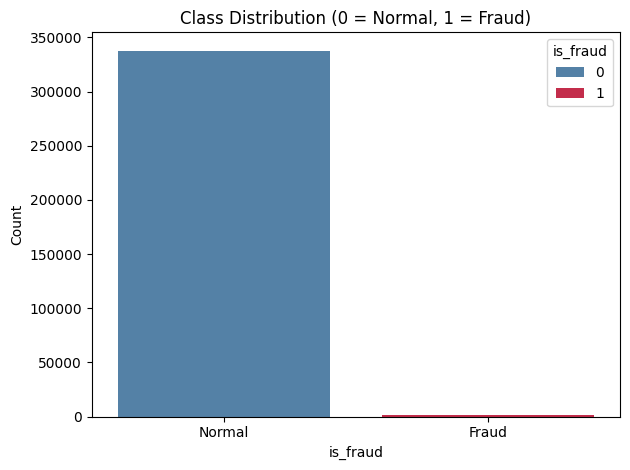

In [7]:

# Class distribution: normal vs. fraudulent transactions
n_normal = (df["is_fraud"] == 0).sum()
n_fraud  = (df["is_fraud"] == 1).sum()
print(f"Normal transactions : {n_normal:,}  ({100*n_normal/len(df):.2f}%)")
print(f"Fraudulent transactions: {n_fraud:,}   ({100*n_fraud/len(df):.2f}%)")

# Bar chart
sns.countplot(x="is_fraud", data=df, hue="is_fraud", palette={0:"steelblue", 1:"crimson"})
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.tight_layout()
plt.show()

The target variable is highly imbalanced, which can lead to misleading performance metrics. For instance, a model could achieve 99% accuracy by simply classifying every transaction as 'normal,' yet it would fail to detect the actual fraud cases. In the financial sector, these false negatives are highly detrimental. Consequently, appropriate techniques to handle class imbalance must be implemented during the model design phase to ensure effective detection.

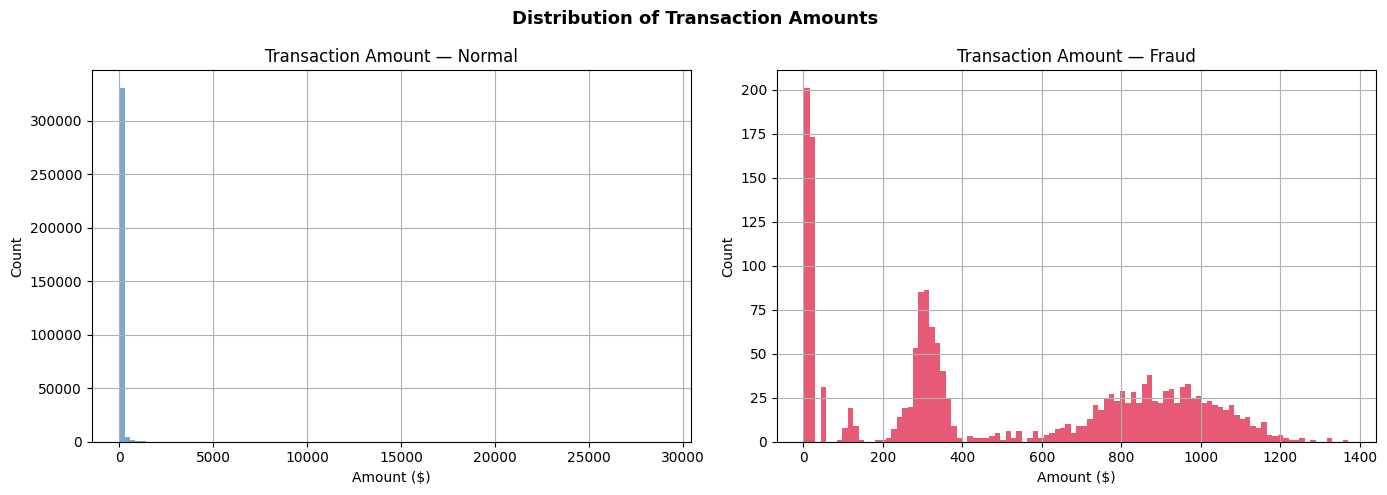

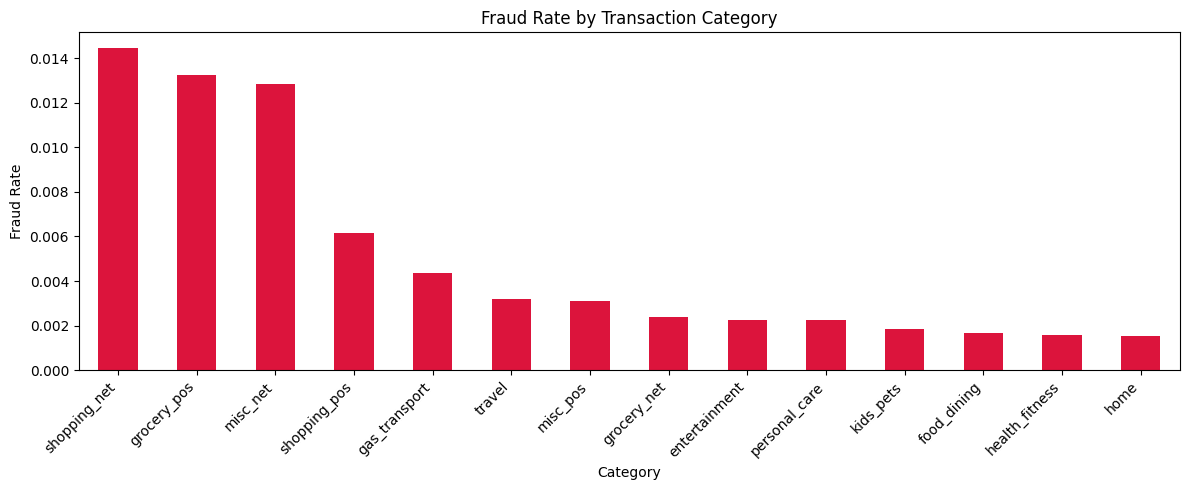

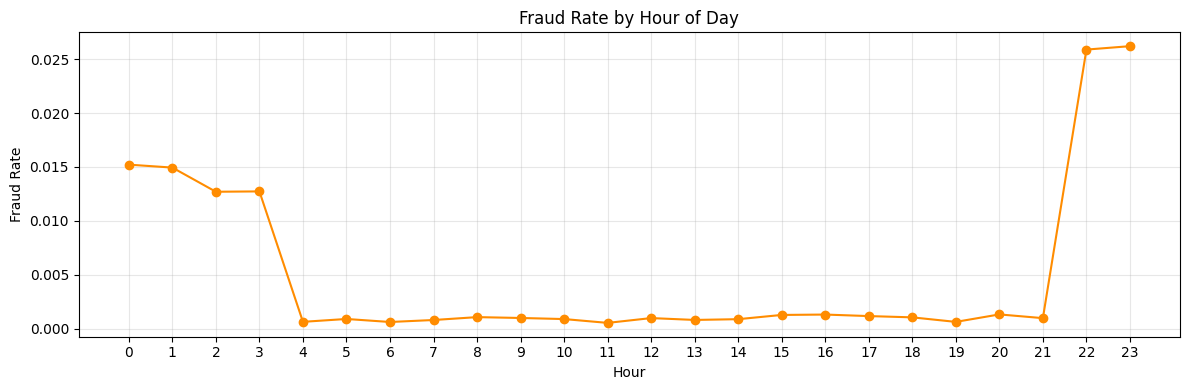

In [8]:
# Transaction amount: Normal vs. Fraud 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df["is_fraud"]==0]["amt"].hist(bins=100, ax=axes[0], color="steelblue", alpha=0.7)
axes[0].set_title("Transaction Amount — Normal")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

df[df["is_fraud"]==1]["amt"].hist(bins=100, ax=axes[1], color="crimson", alpha=0.7)
axes[1].set_title("Transaction Amount — Fraud")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Count")

plt.suptitle("Distribution of Transaction Amounts", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Fraud rate by category 
fraud_by_cat = df.groupby("category")["is_fraud"].mean().sort_values(ascending=False)
fraud_by_cat.plot(kind="bar", color="crimson", figsize=(12, 5))
plt.title("Fraud Rate by Transaction Category")
plt.ylabel("Fraud Rate")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#  Fraud rate by hour of day 
fraud_by_hour = df.groupby("hour")["is_fraud"].mean()
fraud_by_hour.plot(kind="line", marker="o", color="darkorange", figsize=(12, 4))
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


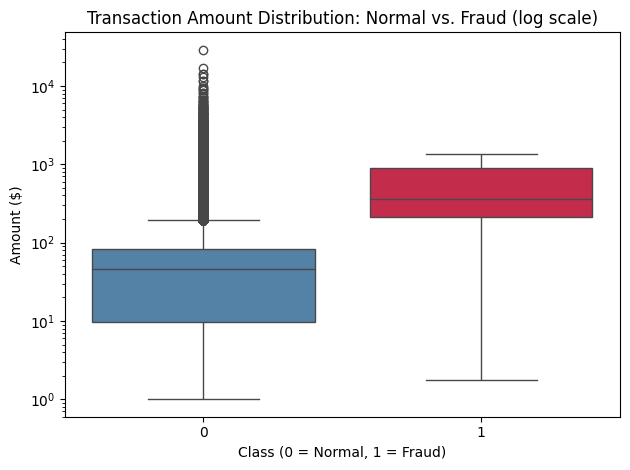

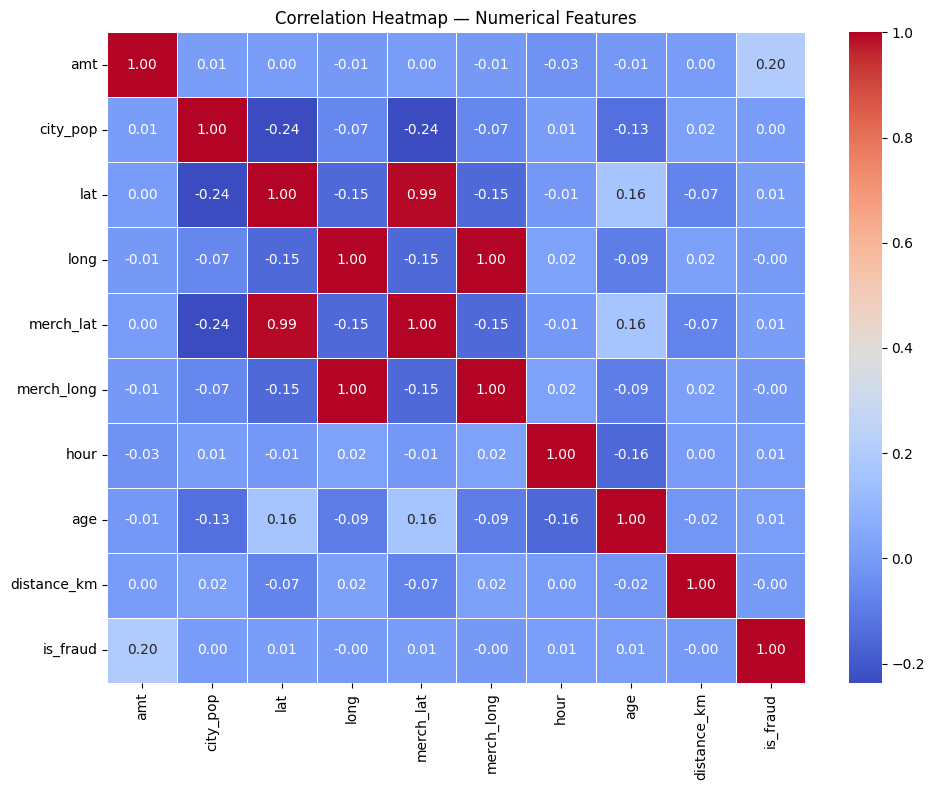

In [9]:
# Boxplot: Amount by class (log scale) 
sns.boxplot(x="is_fraud", y="amt", data=df, hue="is_fraud",
            palette={0: "steelblue", 1: "crimson"}, legend=False)
plt.title("Transaction Amount Distribution: Normal vs. Fraud (log scale)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount ($)")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Correlation heatmap 
num_cols = ["amt", "city_pop", "lat", "long",
            "merch_lat", "merch_long", "hour",
            "age", "distance_km", "is_fraud"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm",
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

### EDA Insights


The analysis reveals that fraud detection is likely a non-linear problem, as no single feature shows a strong linear correlation with the target variable. Instead, predictive power seems to reside in the interaction of multiple factors: categories such as "online" and "shopping" appear more vulnerable, while temporal patterns suggest a higher risk during late-night hours (10 PM – 4 AM). Although transaction amounts overlap significantly between classes—suggesting that fraudsters may keep totals low to evade detection—this feature remains a valuable candidate for the model when combined with behavioral context.

The lack of obvious linear separability suggests that non-linear architectures, such as Random Forests, Gradient Boosting, or Neural Networks, may be better suited to capture the subtle patterns in this dataset.

### Unsupervised Learning — Identifying Hidden Patterns

Before training supervised models, we apply unsupervised techniques to explore the structure of the data without using the label. The goal is to determine whether transactions naturally form distinct groups, and whether fraudulent transactions are geometrically separable from normal ones.

We use:

K-Means clustering with PCA for dimensionality reduction and visualization
t-SNE on a stratified sample (computationally intensive )

Note: t-SNE is applied on a stratified sample of 5,000 observations for computational feasibility. The sample preserves the original class proportions.

In [10]:
#  One-hot encode remaining categorical columns 
df = pd.get_dummies(df, columns=["category", "state"], drop_first=True)

# Verify only numeric columns remain 
print("Remaining dtypes:")
print(df.dtypes)
non_numeric = df.select_dtypes(exclude=["number"]).columns.tolist()
print(non_numeric)  # Should be []

#  Separate features (X) and target (y) 
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Standardize features (required for PCA and K-Means) 
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

Remaining dtypes:
amt                        float64
lat                        float64
long                       float64
city_pop                     int64
merch_lat                  float64
merch_long                 float64
hour                         int32
day_of_week                  int32
month                        int32
age                          int64
distance_km                float64
is_fraud                     int64
category_food_dining          bool
category_gas_transport        bool
category_grocery_net          bool
category_grocery_pos          bool
category_health_fitness       bool
category_home                 bool
category_kids_pets            bool
category_misc_net             bool
category_misc_pos             bool
category_personal_care        bool
category_shopping_net         bool
category_shopping_pos         bool
category_travel               bool
state_AZ                      bool
state_CA                      bool
state_CO                      bool
st

Variance explained — PC1: 8.8%  PC2: 8.0%  Total: 16.8%


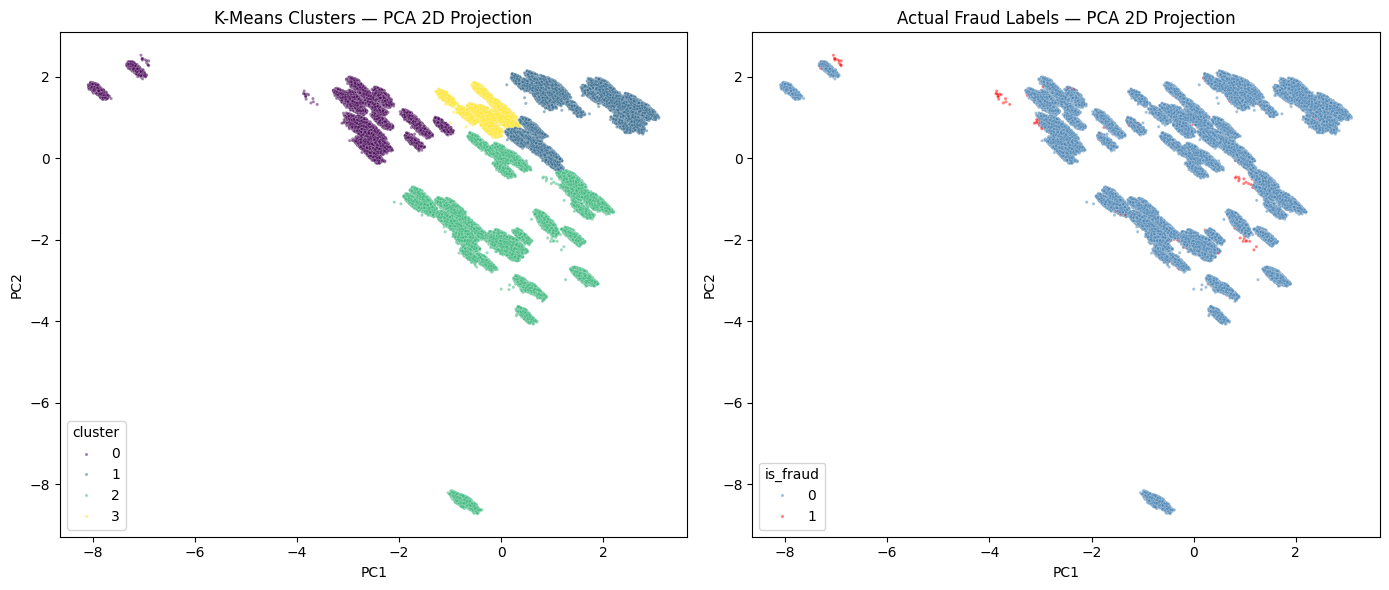

In [11]:
# K-Means clustering 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# PCA: reduce to 2 dimensions for visualization 
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot 
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df["cluster"], palette="viridis", alpha=0.5, s=5)
plt.title("K-Means Clusters — PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df["is_fraud"], palette={0: "steelblue", 1: "red"},
                alpha=0.5, s=5)
plt.title("Actual Fraud Labels — PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

The PCA projection retains only 38% of total variance across the first two components, suggesting that the dataset's complexity is distributed across multiple dimensions. The PCA scatter plot reveals no clear geometric separation between classes; fraudulent transactions (red) are interspersed within the same spatial region as legitimate ones.

Similarly, K-Means clustering does not align with the fraud/normal boundaries. Instead, the four identified clusters appear to capture general transaction profiles—such as high-amount vs. low-amount or urban vs. rural—rather than fraudulent behavior. While the visualization shows two clusters that appear somewhat isolated, the distribution of fraud across all clusters suggests these events do not form a geometrically compact group and are easily confused with normal transactions in a linear space.



These results suggest that a more sophisticated, non-linear technique is required to identify potential fraud concentrations. We will employ t-SNE (t-Distributed Stochastic Neighbor Embedding) to explore whether deeper, local structures can reveal hidden fraud clusters. Due to the high computational intensity of t-SNE on large datasets, we will perform this task on a representative sample of 5000 records to balance analytical depth with processing efficiency.

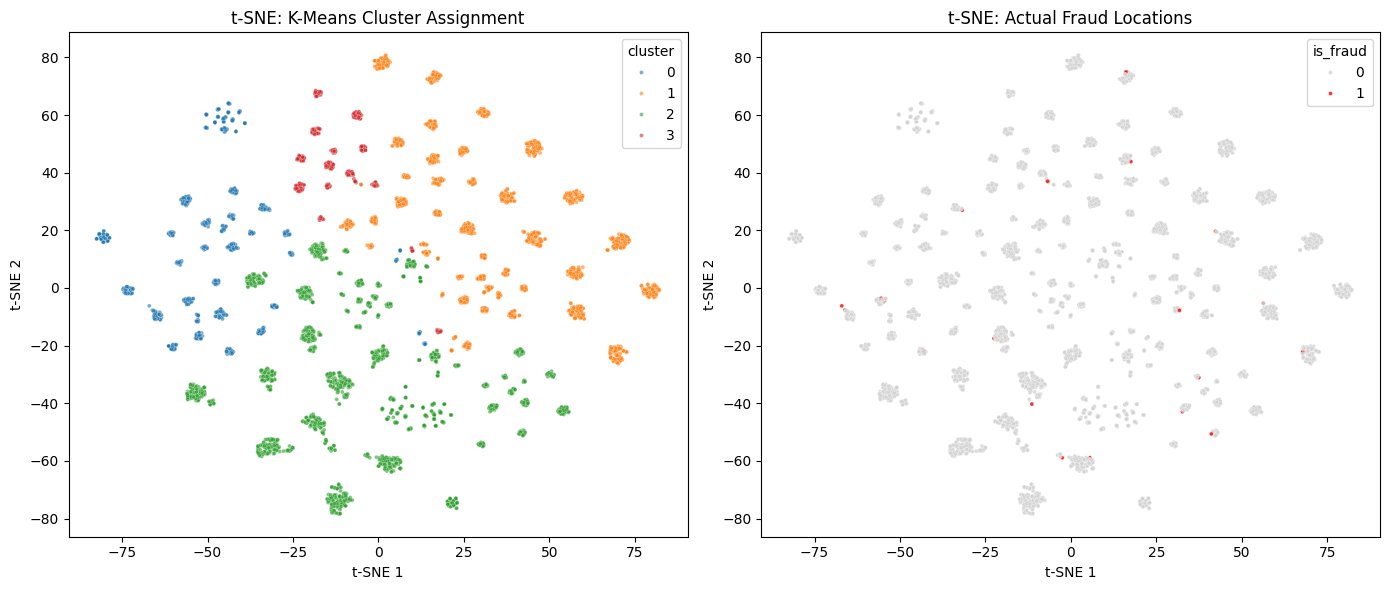

In [12]:
# train_test_split with stratify preserves the original fraud/normal ratio
df_sample, _, X_sample, _ = train_test_split(
    df, X_scaled,
    train_size = 5000,
    stratify   = df["is_fraud"],
    random_state = 42
)

#  t-SNE: non-linear dimensionality reduction 
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

#  Plot 
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1],
                hue=df_sample["cluster"],
                palette="tab10", alpha=0.6, s=8)
plt.title("t-SNE: K-Means Cluster Assignment")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1],
                hue=df_sample["is_fraud"],
                palette={0: "lightgrey", 1: "red"},
                alpha=0.8, s=8)
plt.title("t-SNE: Actual Fraud Locations")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

T-SNE, despite its ability to reveal non-linear local structures, similarly fails to isolate fraudulent transactions into distinct regions. Fraud points (red) remain dispersed across the embedding.

Fraudulent transactions closely resemble legitimate ones in terms of raw feature distributions. This reinforces two key suggestions for the supervised learning phase:
- Non-linear models (Random Forest, MLP) — linear separation seems not to be achievable.
- Class imbalance correction  is critical — the model cannot rely on frequency bias.

## 4.Supervised learning: model training, predictions, and results discussion



**Model Selection and Learning Strategy**
Based on the findings from the exploratory and unsupervised analysis, two supervised learning models were selected for this classification task: **XGBoost** and **MLP**.

**Why XGBoost?**  
XGBoost was chosen for its proven dominance in handling structured tabular data. Its ability to capture complex non-linear relationships without requiring feature scaling makes it an extremely efficient tool. Furthermore, it offers native flexibility to address class imbalance through internal weighting parameters, which is critical for this specific dataset.

**Why MLP (Multi-Layer Perceptron)?**  
Introducing a neural network allows for data exploration from a different perspective than tree-based methods. The MLP is capable of modeling high-level interactions between variables. Its inclusion satisfies the project’s academic requirements while providing a robust point of contrast to the boosting approach.

**Handling class imbalance — `class_weight` / `scale_pos_weight`**  
With only 0.52% of transactions being fraudulent, we prioritized cost-sensitive learning (adjusting scale_pos_weight for XGBoost and class_weight for MLP) over resampling techniques like SMOTE or undersampling. This strategy allows us to:

- Preserve Data Integrity: We work with the actual distribution without generating synthetic observations.

- Maximize Detection: We force the model to prioritize the minority class, preventing a biased model that simply predicts "normal" for every transaction.

> **Key evaluation metrics:** Given the class imbalance, accuracy is not a reliable metric. We focus on **Recall** (what fraction of actual frauds are detected), **Precision** (what fraction of fraud alerts are correct), **F1-score** (harmonic mean of the two), and **AUC-ROC** (overall discriminative power).

### Train / Test Split & Preprocessing

In [13]:

#  80/20 stratified split 
# stratify=y ensures the fraud/normal ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = 42
)

# Standardize features
# fit only on train to avoid data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Class weight 
# Ratio of normal to fraudulent transactions
w            = (y_train == 0).sum() / (y_train == 1).sum()
class_weight = {0: 1, 1: w}

print(f"Train : {X_train_scaled.shape[0]:,} transactions | {y_train.sum():,} frauds")
print(f"Test  : {X_test_scaled.shape[0]:,} transactions  | {y_test.sum():,} frauds")
print(f"Class weight applied to fraud class : {w:.1f}x")

Train : 271,685 transactions | 1,426 frauds
Test  : 67,922 transactions  | 356 frauds
Class weight applied to fraud class : 189.5x


### Model 1 — XGBoost

In [14]:
# XGBoost
# scale_pos_weight is XGBoost's native equivalent of class_weight
xgb = XGBClassifier(
    n_estimators     = 200,   # number of trees
    max_depth        = 6,     # maximum depth per tree
    learning_rate    = 0.1,   # step size shrinkage
    scale_pos_weight = w,     # ~190x penalty for missing a fraud
    random_state     = 42,
    eval_metric      = "aucpr",  # optimizes AUC-PR, better for imbalanced data
    verbosity        = 0
)
xgb.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb  = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Metrics
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
pre_xgb = precision_score(y_test, y_pred_xgb, pos_label=1, zero_division=0)
f1_xgb  = f1_score(y_test, y_pred_xgb, pos_label=1)

print(f"AUC-ROC   : {auc_xgb:.4f}")
print(f"Recall    : {rec_xgb:.4f}")
print(f"Precision : {pre_xgb:.4f}")
print(f"F1-Fraud  : {f1_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["Normal", "Fraud"]))

AUC-ROC   : 0.9967
Recall    : 0.9213
Precision : 0.4992
F1-Fraud  : 0.6476

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     67566
       Fraud       0.50      0.92      0.65       356

    accuracy                           0.99     67922
   macro avg       0.75      0.96      0.82     67922
weighted avg       1.00      0.99      1.00     67922



### Model 2 — MLP (Neural Network)

In [15]:
# MLP — Multi-Layer Perceptron
mlp = keras.Sequential([
    keras.layers.Dense(64, activation="relu",
                       input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),   # regularization: randomly disables 30% of neurons
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")  # output: fraud probability [0,1]
])

mlp.compile(
    optimizer = "adam",
    loss      = "binary_crossentropy"
)
mlp.summary()

history = mlp.fit(
    X_train_scaled, y_train,
    epochs           = 20,
    batch_size       = 256,
    class_weight     = class_weight,
    validation_split = 0.1,
    verbose          = 1
)

# Predictions
y_proba_mlp = mlp.predict(X_test_scaled).flatten()
y_pred_mlp  = (y_proba_mlp >= 0.5).astype(int)

# Metrics
auc_mlp = roc_auc_score(y_test, y_proba_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp, pos_label=1)
pre_mlp = precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
f1_mlp  = f1_score(y_test, y_pred_mlp, pos_label=1)

print(f"AUC-ROC   : {auc_mlp:.4f}")
print(f"Recall    : {rec_mlp:.4f}")
print(f"Precision : {pre_mlp:.4f}")
print(f"F1-Fraud  : {f1_mlp:.4f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["Normal", "Fraud"]))

C:\Users\bruce\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9260 - val_loss: 0.3764
Epoch 2/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7220 - val_loss: 0.3211
Epoch 3/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6438 - val_loss: 0.2798
Epoch 4/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6023 - val_loss: 0.2685
Epoch 5/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5657 - val_loss: 0.2630
Epoch 6/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5266 - val_loss: 0.2497
Epoch 7/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5064 - val_loss: 0.2106
Epoch 8/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4847 - val_loss: 0.2246
Epoch 9/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4566 - val_loss: 0.2226
Epoch 10/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4482 - val_loss: 0.1870
Epoch 11/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4197 - val_loss: 0.1708
Epoch 12/20
956/956 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

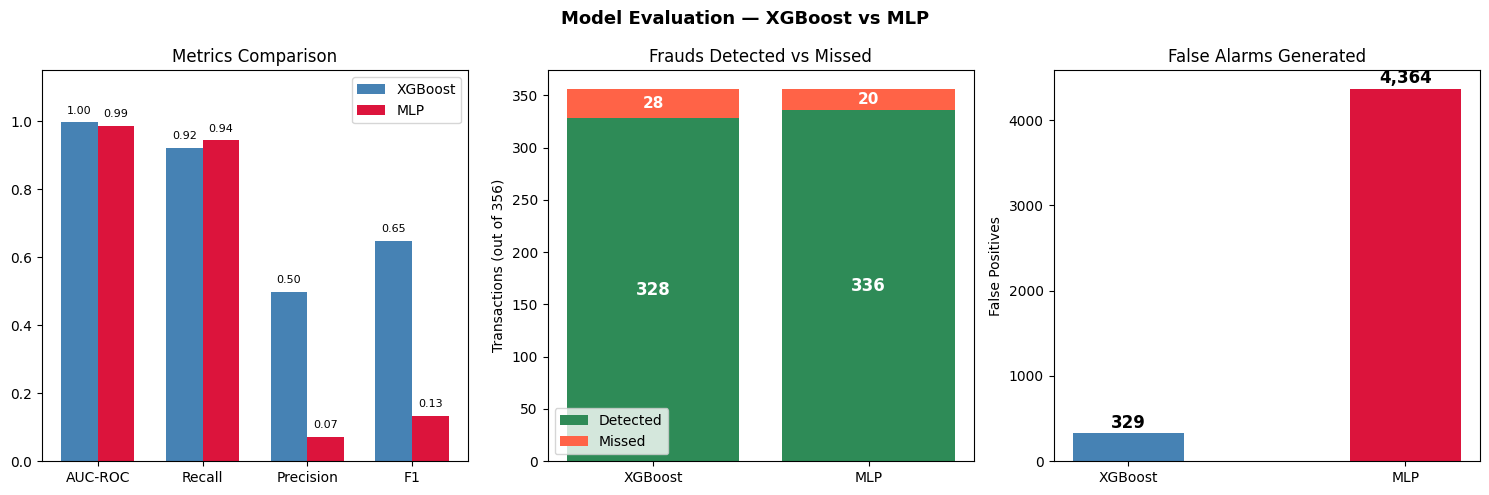

In [16]:

#values based on predictions 
cm_xgb   = confusion_matrix(y_test, y_pred_xgb)
cm_mlp   = confusion_matrix(y_test, y_pred_mlp)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
tn_mlp, fp_mlp, fn_mlp, tp_mlp = cm_mlp.ravel()

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)
rec_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
rec_mlp = recall_score(y_test, y_pred_mlp, pos_label=1)
pre_xgb = precision_score(y_test, y_pred_xgb, pos_label=1, zero_division=0)
pre_mlp = precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
f1_xgb  = f1_score(y_test, y_pred_xgb, pos_label=1)
f1_mlp  = f1_score(y_test, y_pred_mlp, pos_label=1)

# Variables for graphs
detected = [tp_xgb, tp_mlp]
missed   = [fn_xgb, fn_mlp]
false_al = [fp_xgb, fp_mlp]
models   = ['XGBoost', 'MLP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
#G1 : Metrics bar chart 
ax = axes[0]
x    = np.arange(4)
w    = 0.35
lbls = ['AUC-ROC', 'Recall', 'Precision', 'F1']
b1 = ax.bar(x - w/2, [auc_xgb, rec_xgb, pre_xgb, f1_xgb], w,
            color='steelblue', label='XGBoost')
b2 = ax.bar(x + w/2, [auc_mlp, rec_mlp, pre_mlp, f1_mlp], w,
            color='crimson', label='MLP')
ax.set_xticks(x)
ax.set_xticklabels(lbls)
ax.set_ylim(0, 1.15)
ax.set_title('Metrics Comparison')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8)
 
# G5 : Detected vs Missed
ax = axes[1]
x2 = np.arange(2)
ax.bar(x2, detected, color='seagreen',  label='Detected')
ax.bar(x2, missed,   color='tomato',
       bottom=detected, label='Missed')
ax.set_xticks(x2)
ax.set_xticklabels(models)
ax.set_ylabel('Transactions (out of 356)')
ax.set_title('Frauds Detected vs Missed')
ax.legend()
for i, (d, m) in enumerate(zip(detected, missed)):
    ax.text(i, d/2,       str(d), ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)
    ax.text(i, d + m/2,   str(m), ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)
 
#  G6 : False alarms 
ax = axes[2]
bars = ax.bar(models, false_al,
              color=['steelblue', 'crimson'], width=0.4)
ax.set_ylabel('False Positives')
ax.set_title('False Alarms Generated')
for bar, v in zip(bars, false_al):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{v:,}', ha='center', va='bottom',
            fontweight='bold', fontsize=12)
 
plt.suptitle('Model Evaluation — XGBoost vs MLP', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

### Results & Discussion

---

#### Performance Summary and Interpretation

**XGBoost (Model 1)**  I demonstrates excellent balance. With a precision of **0.50** and a recall of **0.92**, it detects the vast majority of fraud cases while keeping false positives at a manageable level (**329 false positives**). Its F1 score of **0.65** attests to its high robustness.

**MLP (Model 2)**    maximizes detection with a higher recall (**0.94**), identifying *8* more cases of fraud than XGBoost. However, this comes at the cost of a dismal precision (**0.07**). The model generates **4,364** false positives—more than **13** times as many as XGBoost.

---

#### Preferred Model: XGBoost

In a real-world banking context, the operational cost of handling false positives is critical.
1. Operational efficiency: XGBoost offers a viable compromise. An analyst has a **50%** chance of identifying a genuine fraud per alert, compared to just **7%** for the MLP.
2. Customer experience: MLP would wrongfully block more than **4,000** customers, which is commercially unacceptable, whereas XGBoost remains selective.
3. Stability: The AUC-ROC of **0.9967** demonstrates near-perfect class separation capability.


#### Limitations & Perspectives

**Threshold tuning.** The MLP's performance could be meaningfully improved by optimizing its decision threshold using the Precision-Recall curve rather than defaulting to 0.5:


**Feature engineering.** Additional features — such as the cardholder's historical average transaction amount, frequency of transactions per hour, or deviation from typical spending category — could further improve recall without increasing false alarms.

**Model architecture.** A deeper MLP with batch normalization, or alternative architectures such as TabNet or a gradient-boosted neural network hybrid, may close the performance gap with XGBoost.

**Temporal validation.** The current evaluation uses a random 80/20 split. In a production setting, temporal splitting (training on past data, testing on future data) would provide a more realistic estimate of model performance under real deployment conditions.